<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/letter_form_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data

In [1]:
#@title Load the data
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip

In [2]:
#@title Load the model weights
!wget https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth

--2025-09-12 04:10:19--  https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ipavlopoulos/greek-letter-vision/refs/heads/main/best_cnn_letter_model.pth [following]
--2025-09-12 04:10:19--  https://raw.githubusercontent.com/ipavlopoulos/greek-letter-vision/refs/heads/main/best_cnn_letter_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17203749 (16M) [application/octet-stream]
Saving to: ‘best_cnn_letter_model.pth’

best_cnn_letter_mod 100%[===================>]  16.41M  --.-KB/s    in 0.1s    


In [3]:
#@title Get the metadata
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])
metadata = pd.read_csv('metadata.csv')
data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [4]:
#@title Dataset development
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

class RandomLacunae(object):
    """
    Apply lacunae-like erasures to simulate missing text regions (irregular blobs).
    """
    def __init__(self, num_lacunae=(1, 4), size_range=(0.02, 0.15), p=0.5, v=0.5):
        """
        Args:
            num_lacunae (tuple): min/max number of lacunae per image
            size_range (tuple): relative size range (as fraction of image area)
            p (float): probability of applying the augmentation
        """
        self.num_lacunae = num_lacunae
        self.size_range = size_range
        self.p = p
        self.v = v

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img).copy()
        h, w = img_np.shape[:2]

        for _ in range(random.randint(*self.num_lacunae)):
            # Random size relative to image
            lacuna_area = random.uniform(*self.size_range) * h * w
            lacuna_w = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))
            lacuna_h = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))

            # Random center
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)

            # Create irregular blob mask using cv2 ellipse + random contour distortion
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(mask, (x, y), (lacuna_w//2, lacuna_h//2),
                        angle=random.randint(0, 180),
                        startAngle=0, endAngle=360,
                        color=1, thickness=-1)

            # Optionally: erode/dilate with noise to add irregularity
            if random.random() < 0.7:
                kernel_size = random.choice([3,5,7])
                kernel = np.ones((kernel_size,kernel_size), np.uint8)
                if random.random() < 0.5:
                    mask = cv2.erode(mask, kernel, iterations=1)
                else:
                    mask = cv2.dilate(mask, kernel, iterations=1)

            # Apply lacuna (set pixels to background = white/255)
            img_np[mask == 1] = 255 * self.v  # assuming grayscale / white parchment

        return torch.tensor(img_np) if isinstance(img, torch.Tensor) else img_np

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [5]:
#@title Train data - not augmented

class SimpleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        # Apply only the test_transform (ToTensor and Normalize)
        if test_transform:
             image = test_transform(image)

        if self.y is not None:
            return image, self.y[idx]
        else:
            return image

train_dataset_no_aug = SimpleDataset(image_data_2d[train_indices_2d], y_train_encoded_2d)
test_dataset_no_aug = SimpleDataset(image_data_2d[test_indices_2d], y_test_encoded_2d)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size)
test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=batch_size)

In [6]:
#@title Source (algorithm)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

def evaluate(model, test_loader, device, label_encoder):
    model.eval()
    correct = 0
    total = 0
    pred, gold = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pred.extend(predicted.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    # Inverse transform the encoded predicted and true labels to get original letter names
    pred = label_encoder.inverse_transform(pred)
    gold = label_encoder.inverse_transform(gold)

    # Display classification report
    print(classification_report(gold, pred, zero_division=0))

    # Display confusion matrix
    cm_2d = confusion_matrix(gold, pred, labels=label_encoder.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
    plt.show()

# TTA/augmentation for embeddings
tta_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(size=(64,64), scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

In [7]:
#@title Load the model
model = CNN2D(num_classes=len(label_encoder.classes_), image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('best_cnn_letter_model.pth', map_location=torch.device(device)))
#evaluate(model, test_loader_2d, device, label_encoder)

<All keys matched successfully>

In [8]:
#@title Extract the embeddings
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                images, targets = batch
                labels.extend(targets.numpy())
            else:
                images = batch
                targets = None

            images = images.to(device)
            emb = model.get_embeddings(images)  # (batch_size, 512)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    if labels:
        labels = np.array(labels)
        return embeddings, labels
    else:
        return embeddings

# Extract embeddings
train_embeddings, train_labels = extract_embeddings(model, train_loader_2d_aug, device)
train_embeddings_no_aug, train_labels_no_aug = extract_embeddings(model, train_loader_no_aug, device)
test_embeddings, test_labels = extract_embeddings(model, test_loader_2d, device)

# Pattern Recognition (in search for letter forms)

Applying KMeans per letter and computing Silhouette Score and visualizing average images:
Letter Alpha: optimal k = 2, silhouette = 0.114
Visualizing average images for Letter: Alpha (KMeans with k=2)


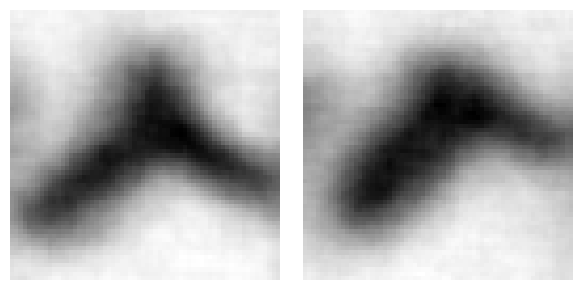

Letter Beta: optimal k = 2, silhouette = 0.112
Visualizing average images for Letter: Beta (KMeans with k=2)


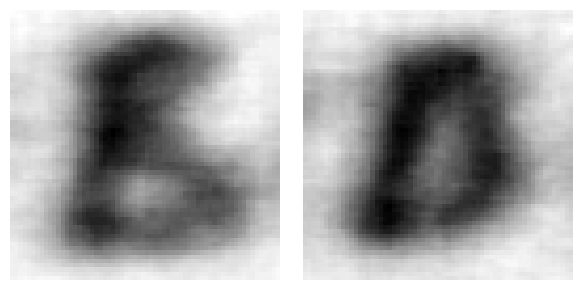

Letter Chi: optimal k = 2, silhouette = 0.102
Visualizing average images for Letter: Chi (KMeans with k=2)


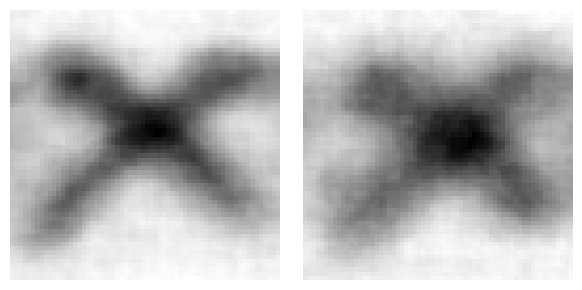

Letter Delta: optimal k = 3, silhouette = 0.117
Visualizing average images for Letter: Delta (KMeans with k=3)


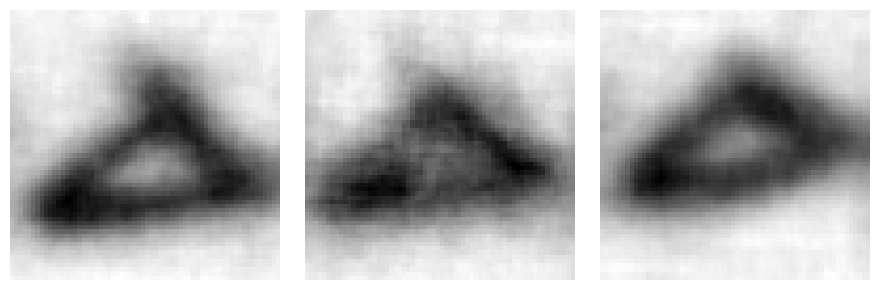

Letter Epsilon: optimal k = 2, silhouette = 0.140
Visualizing average images for Letter: Epsilon (KMeans with k=2)


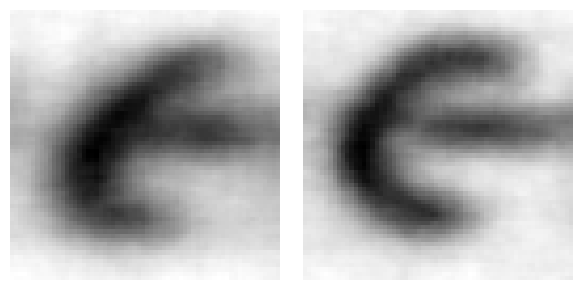

Letter Eta: optimal k = 3, silhouette = 0.096
Visualizing average images for Letter: Eta (KMeans with k=3)


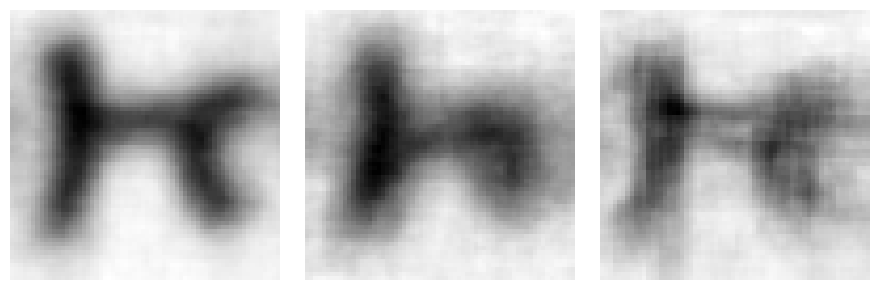

Letter Gamma: optimal k = 2, silhouette = 0.209
Visualizing average images for Letter: Gamma (KMeans with k=2)


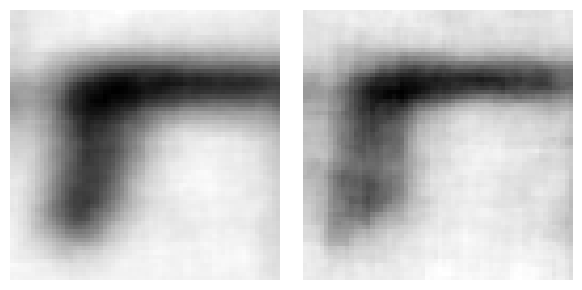

Letter Iota: optimal k = 2, silhouette = 0.192
Visualizing average images for Letter: Iota (KMeans with k=2)


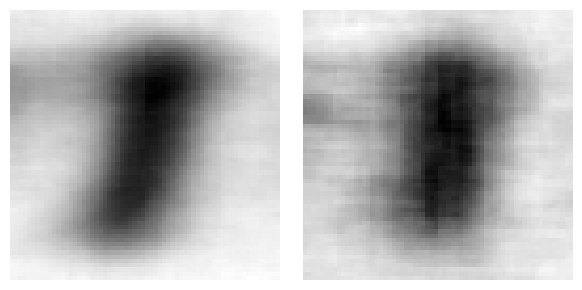

Letter Kappa: optimal k = 2, silhouette = 0.108
Visualizing average images for Letter: Kappa (KMeans with k=2)


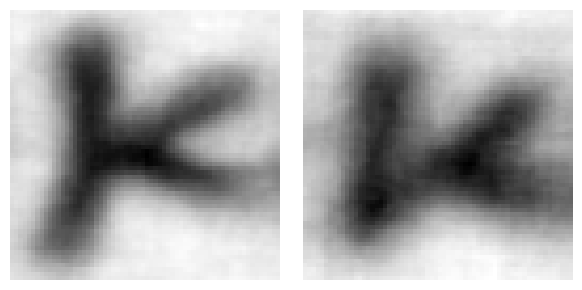

Letter Lambda: optimal k = 2, silhouette = 0.128
Visualizing average images for Letter: Lambda (KMeans with k=2)


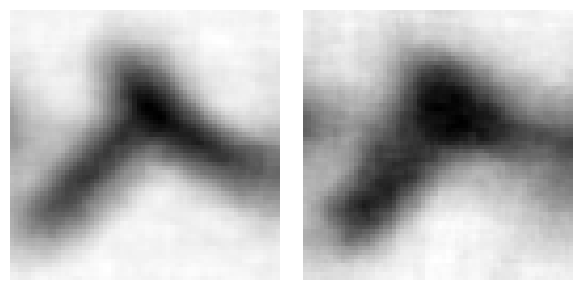

Letter Mu: optimal k = 2, silhouette = 0.126
Visualizing average images for Letter: Mu (KMeans with k=2)


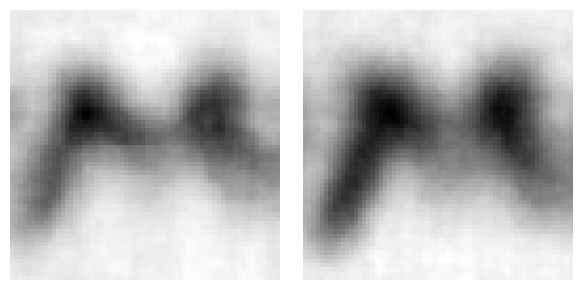

Letter Nu: optimal k = 2, silhouette = 0.113
Visualizing average images for Letter: Nu (KMeans with k=2)


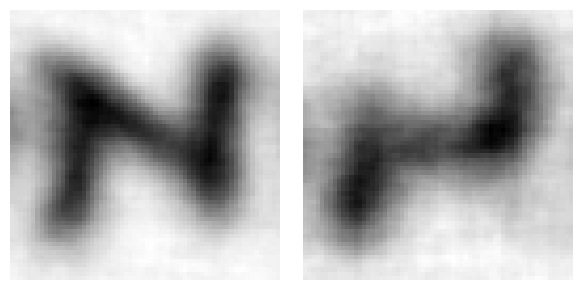

Letter Omega: optimal k = 2, silhouette = 0.165
Visualizing average images for Letter: Omega (KMeans with k=2)


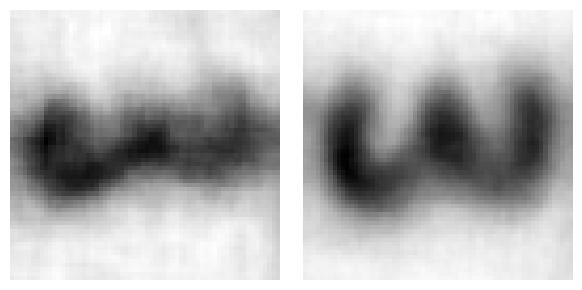

Letter Omicron: optimal k = 2, silhouette = 0.138
Visualizing average images for Letter: Omicron (KMeans with k=2)


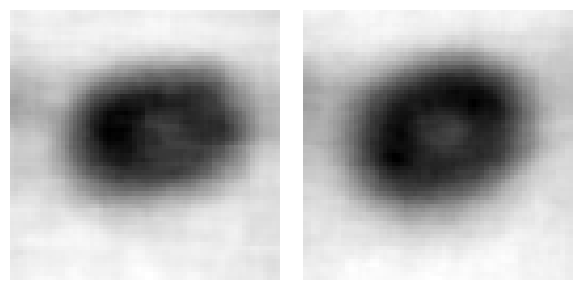

Letter Phi: optimal k = 2, silhouette = 0.214
Visualizing average images for Letter: Phi (KMeans with k=2)


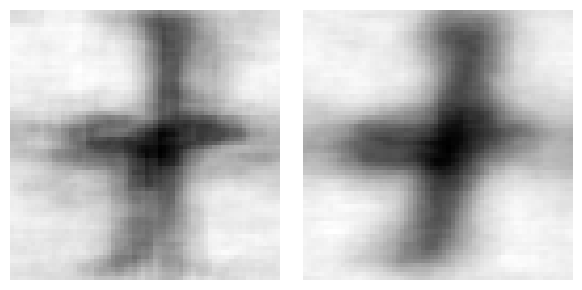

Letter Pi: optimal k = 3, silhouette = 0.093
Visualizing average images for Letter: Pi (KMeans with k=3)


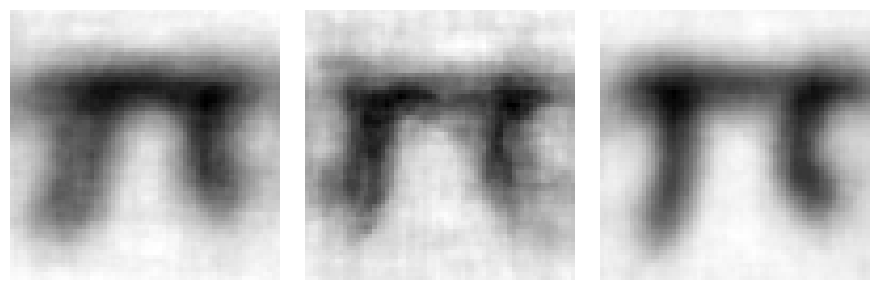

Letter Psi: optimal k = 2, silhouette = 0.145
Visualizing average images for Letter: Psi (KMeans with k=2)


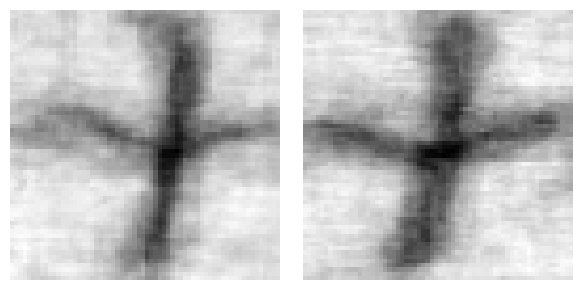

Letter Rho: optimal k = 2, silhouette = 0.112
Visualizing average images for Letter: Rho (KMeans with k=2)


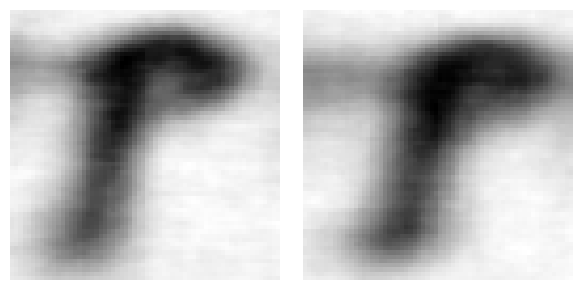

Letter Sigma: optimal k = 2, silhouette = 0.144
Visualizing average images for Letter: Sigma (KMeans with k=2)


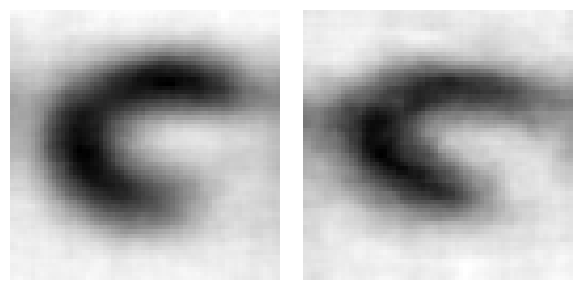

Letter Tau: optimal k = 2, silhouette = 0.139
Visualizing average images for Letter: Tau (KMeans with k=2)


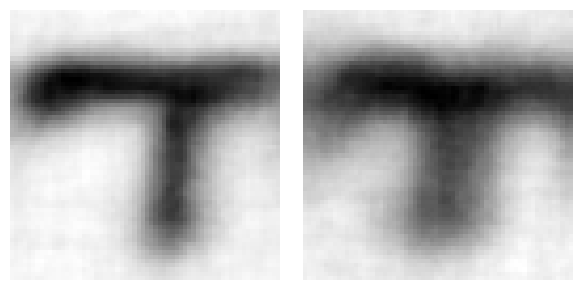

Letter Theta: optimal k = 2, silhouette = 0.118
Visualizing average images for Letter: Theta (KMeans with k=2)


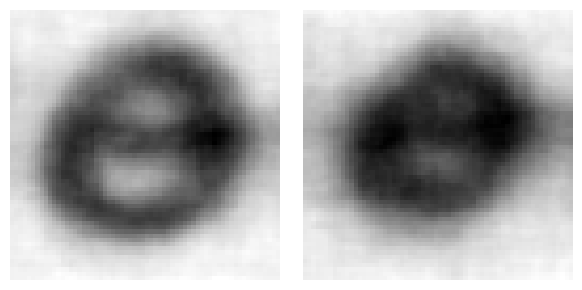

Letter Upsilon: optimal k = 2, silhouette = 0.133
Visualizing average images for Letter: Upsilon (KMeans with k=2)


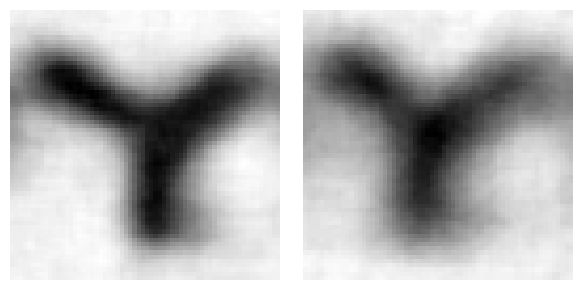

Letter Xi: optimal k = 3, silhouette = 0.098
Visualizing average images for Letter: Xi (KMeans with k=3)


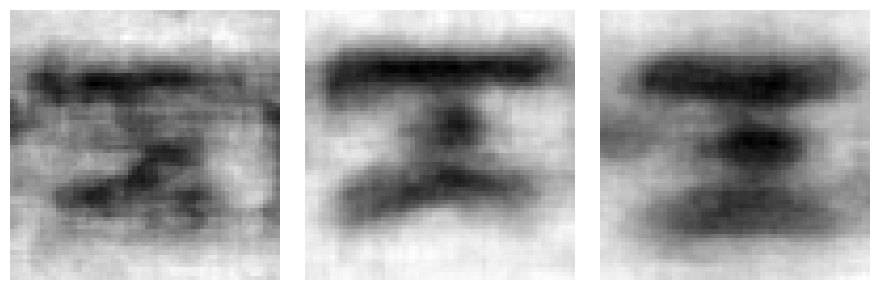

Letter Zeta: optimal k = 2, silhouette = 0.118
Visualizing average images for Letter: Zeta (KMeans with k=2)


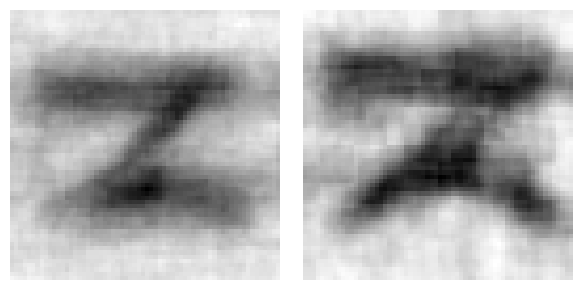


Optimal number of clusters per letter using KMeans:
Alpha: 2
Beta: 2
Chi: 2
Delta: 3
Epsilon: 2
Eta: 3
Gamma: 2
Iota: 2
Kappa: 2
Lambda: 2
Mu: 2
Nu: 2
Omega: 2
Omicron: 2
Phi: 2
Pi: 3
Psi: 2
Rho: 2
Sigma: 2
Tau: 2
Theta: 2
Upsilon: 2
Xi: 3
Zeta: 2


In [9]:
#@title KMeans per Letter (using CNN embeddings)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import torch

num_classes = len(np.unique(train_labels_no_aug))

optimal_clusters = {}

print("Applying KMeans per letter and computing Silhouette Score and visualizing average images:")

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(train_labels_no_aug == c)[0]
    class_embeddings = train_embeddings_no_aug[class_indices]

    letter_name = label_encoder.inverse_transform([c])[0]

    if len(class_embeddings) < 2:
        print(f"Letter {letter_name}: Too few samples ({len(class_embeddings)}). Skipping clustering and visualization.")
        optimal_clusters[c] = 1 # Assume 1 cluster if too few samples
        continue

    # 2. Try different k
    best_k = 1
    best_score = -1
    # Limit k to a reasonable range, e.g., up to 5 or half the number of samples
    max_k_to_try = min(5, len(class_embeddings) // 2 + 1)
    if max_k_to_try < 2:
         print(f"Letter {letter_name}: Too few samples ({len(class_embeddings)}) to try k >= 2 for silhouette score. Optimal k set to 1.")
         optimal_clusters[c] = 1
         continue

    for k in range(2, max_k_to_try):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        cluster_labels = kmeans.fit_predict(class_embeddings)

        # Check if all samples were assigned to a cluster (silhouette requires at least 2 clusters with samples)
        if len(np.unique(cluster_labels)) < 2:
             print(f"Letter {letter_name} with k={k}: Only found 1 cluster. Cannot compute Silhouette.")
             continue

        score = silhouette_score(class_embeddings, cluster_labels)

        if score > best_score:
            best_score = score
            best_k = k

    optimal_clusters[c] = best_k
    print(f"Letter {letter_name}: optimal k = {best_k}, silhouette = {best_score:.3f}")

    # --- Visualize Average Image per Cluster ---
    print(f"Visualizing average images for Letter: {letter_name} (KMeans with k={best_k})")

    # Re-run KMeans with the optimal k to get the cluster assignments
    kmeans_optimal = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    clusters = kmeans_optimal.fit_predict(class_embeddings)

    plt.figure(figsize=(best_k * 3, 3)) # Adjust figure size based on number of clusters
    #plt.suptitle(f"Average Images for Letter: {letter_name} (KMeans with k={best_k})", fontsize=14)

    for cluster_id in range(best_k):
        # Find the indices of samples belonging to this cluster within the subset of this letter's embeddings
        cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]

        if len(cluster_samples_indices_in_subset) > 0:
            # Get the original image data for these samples
            indices_in_full_train_set = class_indices[cluster_samples_indices_in_subset]

            # Collect all images for this cluster
            cluster_images = []
            for idx_in_train_set in indices_in_full_train_set:
                 try:
                     # Assuming train_loader_no_aug provides access to the original images
                     # and that its dataset is aligned with the indices used for splitting
                     img, _ = train_loader_no_aug.dataset[idx_in_train_set]
                     if isinstance(img, torch.Tensor):
                        img = img.squeeze().cpu().numpy()
                     cluster_images.append(img)
                 except IndexError:
                     print(f"Error retrieving image for letter {letter_name}, cluster {cluster_id} at training set index {idx_in_train_set}.")
                     continue

            if cluster_images:
                # Calculate the average image for this cluster
                average_image = np.mean(cluster_images, axis=0)

                plt.subplot(1, best_k, cluster_id + 1)
                plt.imshow(average_image, cmap="gray")
                #plt.title(f"Cluster {cluster_id} (n={len(cluster_images)})")
                plt.axis("off")
            else:
                print(f"Warning: No images found for cluster {cluster_id} of letter {letter_name}.")

        else:
            print(f"Warning: Cluster {cluster_id} for letter {letter_name} is empty.")

    plt.tight_layout()
    plt.show()

print("\nOptimal number of clusters per letter using KMeans:")
for c, k in optimal_clusters.items():
    letter_name = label_encoder.inverse_transform([c])[0]
    print(f"{letter_name}: {k}")

Applying Spectral Clustering per letter and computing Silhouette Score:
Letter Alpha: optimal k = 2, silhouette = 0.085
Letter Beta: optimal k = 2, silhouette = 0.105
Letter Chi: optimal k = 2, silhouette = 0.116
Letter Delta: optimal k = 3, silhouette = 0.095
Letter Epsilon: optimal k = 2, silhouette = 0.127
Letter Eta: optimal k = 2, silhouette = 0.116
Letter Gamma: optimal k = 2, silhouette = 0.191
Letter Iota: optimal k = 2, silhouette = 0.160
Letter Kappa: optimal k = 2, silhouette = 0.104
Letter Lambda: optimal k = 2, silhouette = 0.134
Letter Mu: optimal k = 2, silhouette = 0.105
Letter Nu: optimal k = 2, silhouette = 0.121
Letter Omega: optimal k = 2, silhouette = 0.163
Letter Omicron: optimal k = 2, silhouette = 0.118
Letter Phi: optimal k = 2, silhouette = 0.186
Letter Pi: optimal k = 2, silhouette = 0.131
Letter Psi: optimal k = 2, silhouette = 0.113
Letter Rho: optimal k = 4, silhouette = 0.077
Letter Sigma: optimal k = 2, silhouette = 0.137
Letter Tau: optimal k = 2, silho

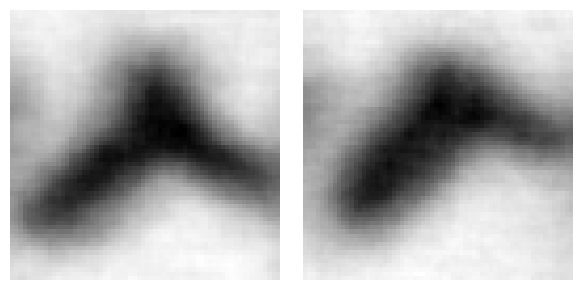


Processing Letter for Visualization: Beta (Optimal k = 2)


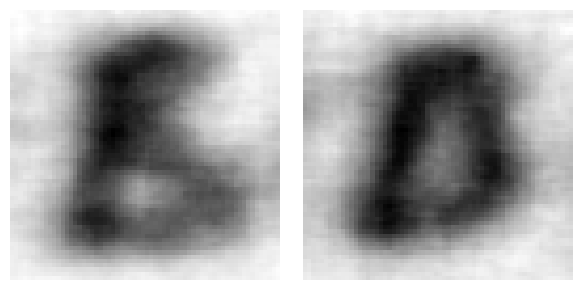


Processing Letter for Visualization: Chi (Optimal k = 2)


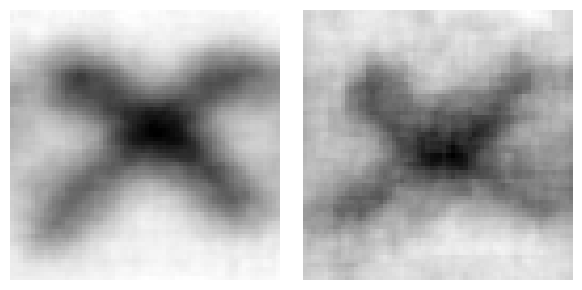


Processing Letter for Visualization: Delta (Optimal k = 3)


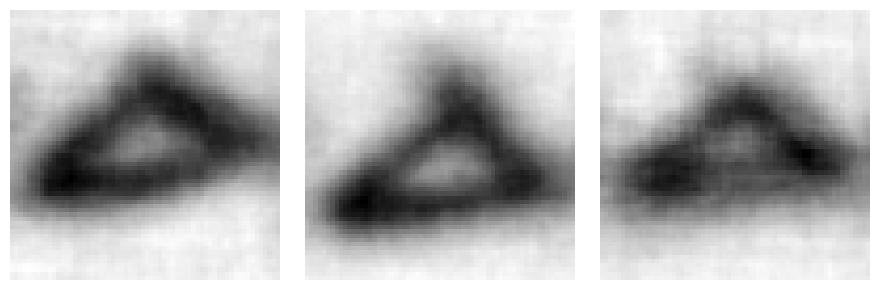


Processing Letter for Visualization: Epsilon (Optimal k = 2)


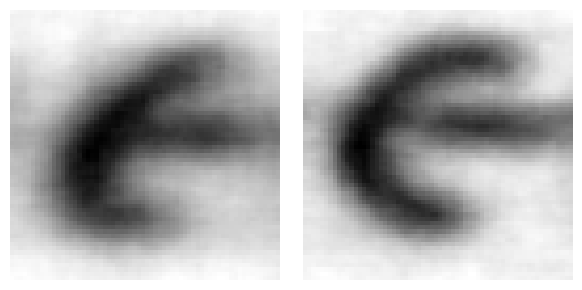


Processing Letter for Visualization: Eta (Optimal k = 2)


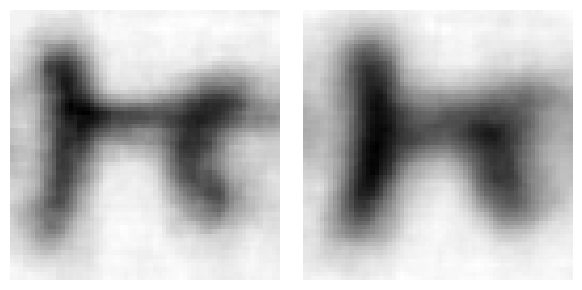


Processing Letter for Visualization: Gamma (Optimal k = 2)


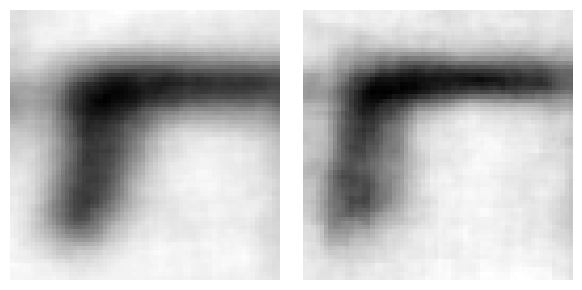


Processing Letter for Visualization: Iota (Optimal k = 2)


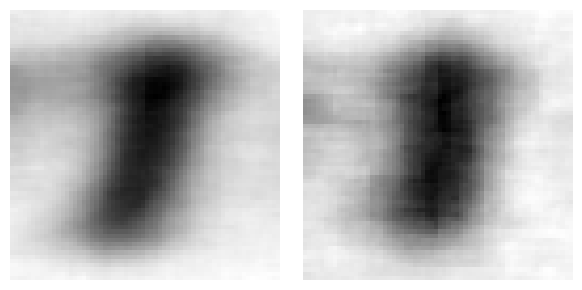


Processing Letter for Visualization: Kappa (Optimal k = 2)


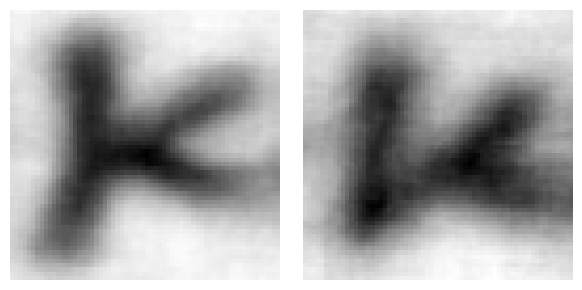


Processing Letter for Visualization: Lambda (Optimal k = 2)


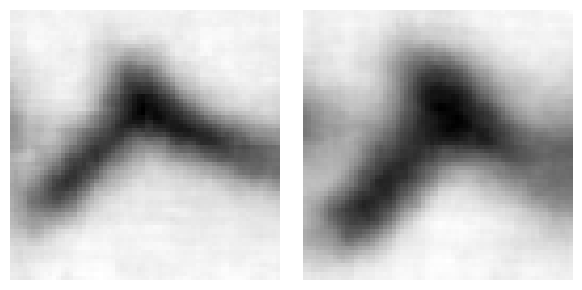


Processing Letter for Visualization: Mu (Optimal k = 2)


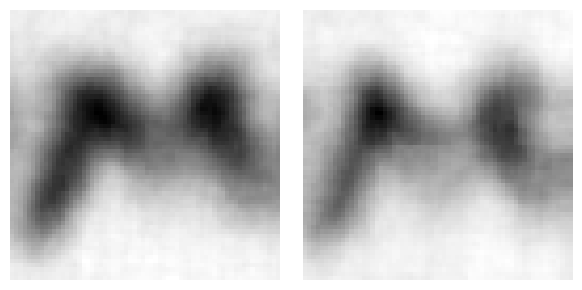


Processing Letter for Visualization: Nu (Optimal k = 2)


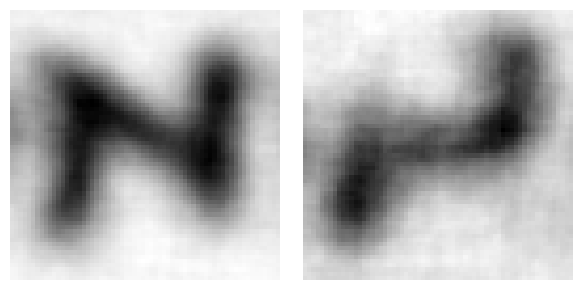


Processing Letter for Visualization: Omega (Optimal k = 2)


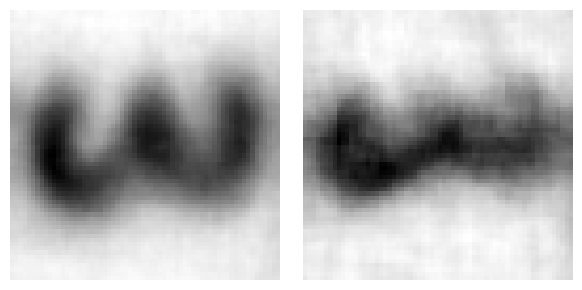


Processing Letter for Visualization: Omicron (Optimal k = 2)


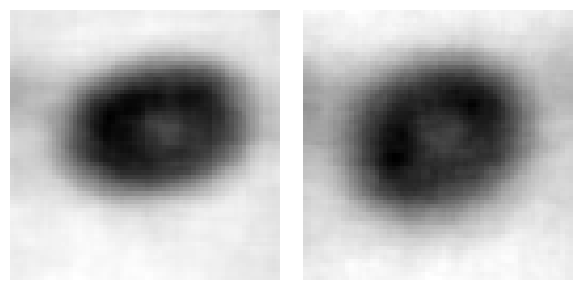


Processing Letter for Visualization: Phi (Optimal k = 2)


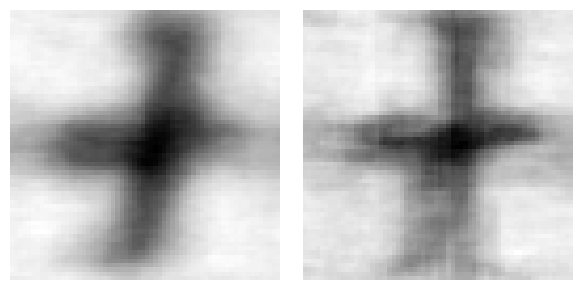


Processing Letter for Visualization: Pi (Optimal k = 2)


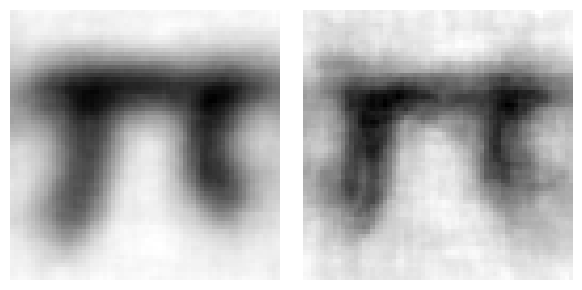


Processing Letter for Visualization: Psi (Optimal k = 2)


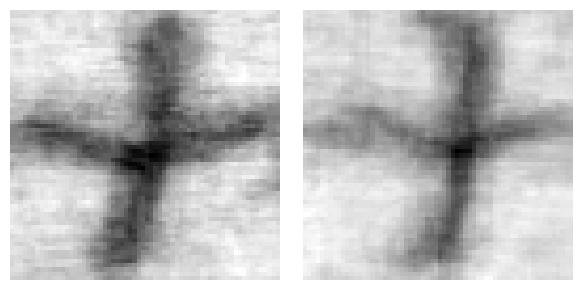


Processing Letter for Visualization: Rho (Optimal k = 4)


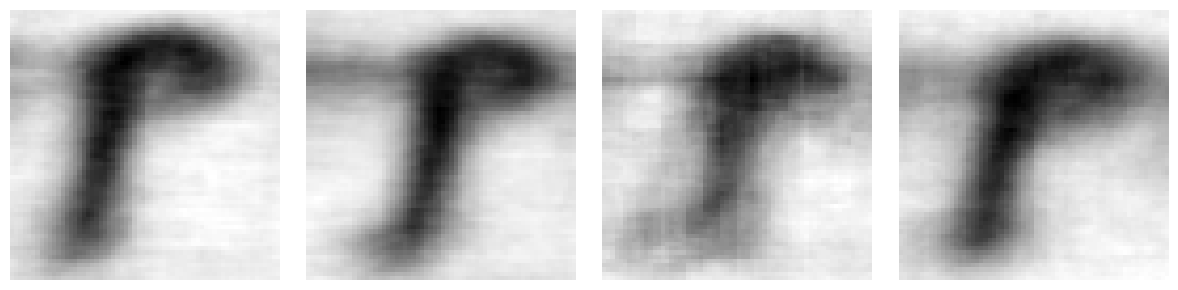


Processing Letter for Visualization: Sigma (Optimal k = 2)


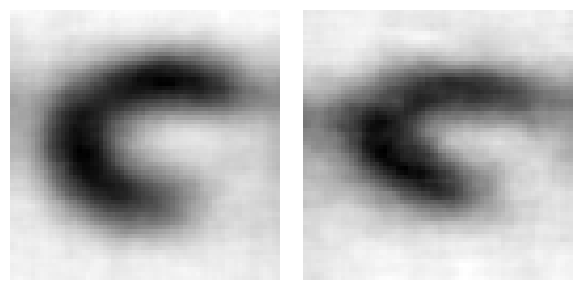


Processing Letter for Visualization: Tau (Optimal k = 2)


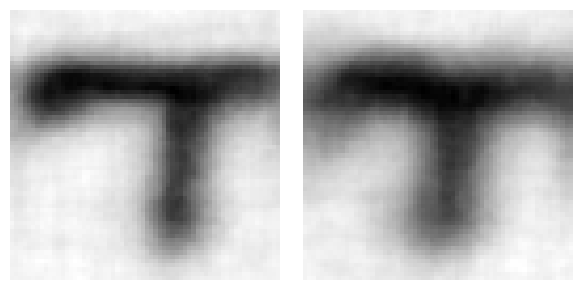


Processing Letter for Visualization: Theta (Optimal k = 2)


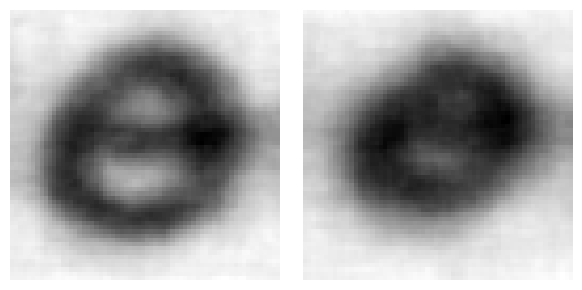


Processing Letter for Visualization: Upsilon (Optimal k = 2)


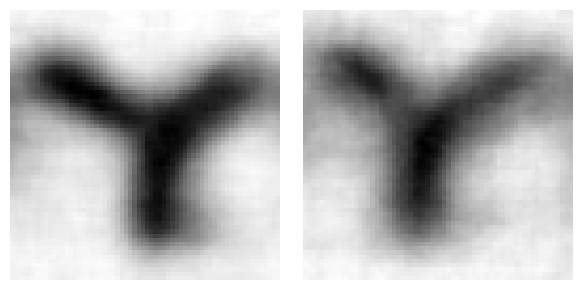


Processing Letter for Visualization: Xi (Optimal k = 2)


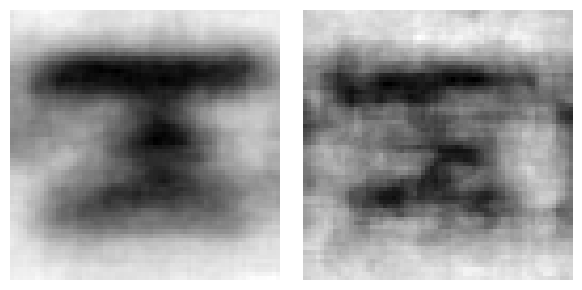


Processing Letter for Visualization: Zeta (Optimal k = 2)


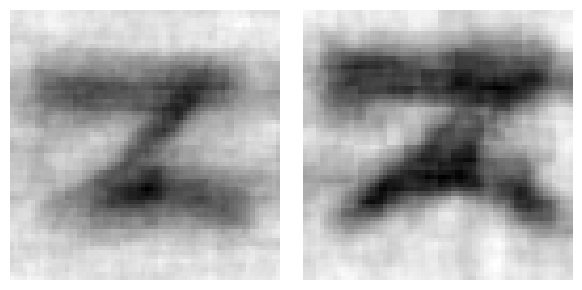

In [10]:
#@title Calculate and Visualize Spectral Clustering Average Images per Cluster per Letter
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.distance import cdist
from scipy.stats import mode # Import mode

# Assuming embeddings and labels contain the CNN embeddings and labels before augmentation
# Assuming train_loader_no_aug provides access to the original images
# Assuming train_indices_2d and image_data_2d are available

# Use embeddings and labels from the training set before augmentation
embeddings = train_embeddings_no_aug
labels = train_labels_no_aug

num_classes = len(np.unique(labels))

optimal_clusters_spectral = {}

print("Applying Spectral Clustering per letter and computing Silhouette Score:")

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices]
    class_labels_encoded = labels[class_indices] # True labels for this class (all the same)

    letter_name = label_encoder.inverse_transform([c])[0]

    if len(class_embeddings) < 5:
        # Too few samples to cluster
        print(f"Letter {letter_name}: Too few samples ({len(class_embeddings)}). Skipping clustering.")
        optimal_clusters_spectral[c] = 1 # Assume 1 cluster if too few samples
        continue

    # 2. Try different k for Spectral Clustering
    best_k = 1
    best_score = -1

    # Spectral Clustering can be sensitive to the number of clusters and data size.
    # Let's limit the range of k and use 'nearest_neighbors' affinity for efficiency.
    # Also, setting n_init higher for kmeans initialization in 'discretize' can be helpful.
    for k in range(2, min(10, len(class_embeddings) // 2 + 1)): # Try up to 10 clusters or half the data size
        try:
            # Use 'nearest_neighbors' affinity for potentially better performance on larger datasets
            spectral = SpectralClustering(n_clusters=k,
                                          assign_labels='discretize', # or 'kmeans'
                                          random_state=42,
                                          affinity='nearest_neighbors',
                                          n_neighbors=min(10, len(class_embeddings) - 1)) # Number of neighbors

            cluster_labels = spectral.fit_predict(class_embeddings)

            # Check if all samples were assigned to a cluster (silhouette requires at least 2 clusters with samples)
            if len(np.unique(cluster_labels)) < 2:
                 print(f"Letter {letter_name} with k={k}: Only found 1 cluster. Cannot compute Silhouette.")
                 continue

            # Calculate silhouette score
            score = silhouette_score(class_embeddings, cluster_labels)

            if score > best_score:
                best_score = score
                best_k = k
        except Exception as e:
            print(f"Error clustering Letter {letter_name} with k={k}: {e}")
            continue

    optimal_clusters_spectral[c] = best_k
    print(f"Letter {letter_name}: optimal k = {best_k}, silhouette = {best_score:.3f}")

print("\nOptimal number of clusters per letter using Spectral Clustering:")
for c, k in optimal_clusters_spectral.items():
    letter_name = label_encoder.inverse_transform([c])[0]
    print(f"{letter_name}: {k}")

# --- Visualization Part ---
print("\nVisualizing average images per cluster per letter (Spectral Clustering):")

for c, optimal_k in optimal_clusters_spectral.items():
    letter = label_encoder.inverse_transform([c])[0]
    print(f"\nProcessing Letter for Visualization: {letter} (Optimal k = {optimal_k})")

    # Subset embeddings and labels for this letter from the TRAINING SET
    class_indices_in_train_set = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices_in_train_set]

    if len(class_embeddings) < optimal_k:
         print(f"Not enough samples for letter {letter} in the training set ({len(class_embeddings)}) to form {optimal_k} clusters. Skipping visualization.")
         continue
    if len(class_embeddings) < 2 and optimal_k > 1:
         print(f"Too few samples ({len(class_embeddings)}) for letter {letter} to perform clustering with k={optimal_k}. Skipping visualization.")
         continue


    # Perform Spectral Clustering with the optimal k (again, to get clusters for visualization)
    try:
        n_neighbors_sc = min(10, len(class_embeddings) - 1)
        if n_neighbors_sc < 1 and optimal_k > 1:
             print(f"Not enough samples to determine nearest neighbors for letter {letter}. Skipping visualization.")
             continue

        spectral = SpectralClustering(n_clusters=optimal_k,
                                      assign_labels='discretize', # or 'kmeans'
                                      random_state=42,
                                      affinity='nearest_neighbors',
                                      n_neighbors=n_neighbors_sc)

        clusters = spectral.fit_predict(class_embeddings)

        if len(np.unique(clusters)) < optimal_k:
             print(f"Spectral Clustering found less than {optimal_k} distinct clusters for letter {letter}. Cannot visualize average images for {optimal_k} clusters.")
             if len(np.unique(clusters)) == 1 and optimal_k == 1:
                 pass
             else:
                 continue


        plt.figure(figsize=(optimal_k * 3, 3))
        #plt.suptitle(f"Average Images for Letter: {letter} (Spectral Clustering with k={optimal_k})", fontsize=14)

        for cluster_id in range(optimal_k):
            cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]

            if len(cluster_samples_indices_in_subset) > 0:
                indices_in_full_train_set = class_indices_in_train_set[cluster_samples_indices_in_subset]

                cluster_images = []
                for idx_in_train_set in indices_in_full_train_set:
                     try:
                         img, _ = train_loader_no_aug.dataset[idx_in_train_set]
                         if isinstance(img, torch.Tensor):
                            img = img.squeeze().cpu().numpy()
                         cluster_images.append(img)
                     except IndexError:
                         print(f"Error retrieving image for letter {letter}, cluster {cluster_id} at training set index {idx_in_train_set}.")
                         continue

                if cluster_images:
                    average_image = np.mean(cluster_images, axis=0)

                    plt.subplot(1, optimal_k, cluster_id + 1)
                    plt.imshow(average_image, cmap="gray")
                    #plt.title(f"Cluster {cluster_id} (n={len(cluster_images)})")
                    plt.axis("off")
                else:
                    print(f"Warning: No images found for cluster {cluster_id} of letter {letter}.")

            else:
                print(f"Warning: Cluster {cluster_id} for letter {letter} is empty.")


        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error performing Spectral Clustering for letter {letter} with k={optimal_k}: {e}")
        continue

In [11]:
#@title DBSCAN per Letter and Visualize Average Images
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.distance import cdist

# Assuming embeddings and labels contain the CNN embeddings and labels before augmentation
# Assuming train_loader_no_aug provides access to the original images
# Assuming train_indices_2d and image_data_2d are available

# Use embeddings and labels from the training set before augmentation
embeddings = train_embeddings_no_aug
labels = train_labels_no_aug

num_classes = len(np.unique(labels))

print("Applying DBSCAN per letter and visualizing average images per cluster:")

# DBSCAN parameters (these may need tuning based on your data)
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
# A point is a core point if it has more than min_samples points in its neighborhood.
# Adjust these parameters based on the characteristics of your embeddings.
# You might need to experiment with different values.
dbscan_params = {'eps': 0.5, 'min_samples': 5} # Example parameters, tune as needed

for c in range(num_classes):
    letter = label_encoder.inverse_transform([c])[0]
    print(f"\nProcessing Letter: {letter}")

    # Subset embeddings of this class
    class_indices_in_train_set = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices_in_train_set]

    if len(class_embeddings) < dbscan_params['min_samples']:
        print(f"Letter {letter}: Too few samples ({len(class_embeddings)}) for DBSCAN with min_samples={dbscan_params['min_samples']}. Skipping clustering and visualization.")
        continue

    # Apply DBSCAN
    try:
        dbscan = DBSCAN(eps=dbscan_params['eps'], min_samples=dbscan_params['min_samples'])
        clusters = dbscan.fit_predict(class_embeddings)

        # Number of clusters in labels, ignoring noise if present.
        n_clusters_ = len(set(clusters)) - (1 if -1 in clusters else 0)
        unique_clusters = set(clusters) - {-1} # Exclude noise cluster (-1)

        if n_clusters_ == 0:
            print(f"Letter {letter}: DBSCAN found no clusters (only noise). Skipping visualization.")
            continue

        print(f"Letter {letter}: DBSCAN found {n_clusters_} clusters (excluding noise).")

        plt.figure(figsize=(len(unique_clusters) * 3, 3)) # Adjust figure size based on number of clusters
        #plt.suptitle(f"Average Images for Letter: {letter} (DBSCAN)", fontsize=14)

        cluster_count = 0
        for cluster_id in sorted(list(unique_clusters)): # Iterate through valid cluster IDs
            # Find the indices of samples belonging to this cluster within the subset of this letter's embeddings
            cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]

            if len(cluster_samples_indices_in_subset) > 0:
                # Get the original image data for these samples
                indices_in_full_train_set = class_indices_in_train_set[cluster_samples_indices_in_subset]

                # Collect all images for this cluster
                cluster_images = []
                for idx_in_train_set in indices_in_full_train_set:
                     try:
                         img, _ = train_loader_no_aug.dataset[idx_in_train_set]
                         if isinstance(img, torch.Tensor):
                            img = img.squeeze().cpu().numpy()
                         cluster_images.append(img)
                     except IndexError:
                         print(f"Error retrieving image for letter {letter}, cluster {cluster_id} at training set index {idx_in_train_set}.")
                         continue

                if cluster_images:
                    # Calculate the average image for this cluster
                    average_image = np.mean(cluster_images, axis=0)

                    cluster_count += 1
                    plt.subplot(1, len(unique_clusters), cluster_count) # Use cluster_count for subplot indexing
                    plt.imshow(average_image, cmap="gray")
                    #plt.title(f"Cluster {cluster_id} (n={len(cluster_images)})")
                    plt.axis("off")
                else:
                    print(f"Warning: No images found for cluster {cluster_id} of letter {letter}.")

            # Note: DBSCAN can produce empty clusters if min_samples is too high relative to the data density.
            # The code above handles this by only iterating through unique_clusters (excluding -1).

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error performing DBSCAN for letter {letter}: {e}")
        continue

print("\nDBSCAN clustering and visualization complete.")

Applying DBSCAN per letter and visualizing average images per cluster:

Processing Letter: Alpha
Letter Alpha: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Beta
Letter Beta: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Chi
Letter Chi: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Delta
Letter Delta: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Epsilon
Letter Epsilon: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Eta
Letter Eta: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Gamma
Letter Gamma: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Iota
Letter Iota: DBSCAN found no clusters (only noise). Skipping visualization.

Processing Letter: Kappa
Letter Kappa: DBSCAN found no clusters (only noise). Skipping visualization.

Processin